In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# Exercício 1

1. Gere uma amostra de tamanho $K$ de uma variável com distribuição binomial negativa com parâmetros $p$ $r$ utilizando os três métodos vistos em sala: via Bernoullis, via soma de geométricas, via recursão.
2. Compare com uma amostra gerada pelo numpy usando histogramas.
3. Compare o tempo dos três métodos como visto nos labs anteriores.



1.1.1 - Recursão

(array([ 27., 122., 248., 277., 127., 117.,  55.,  19.,   4.,   4.]),
 array([10. , 12.8, 15.6, 18.4, 21.2, 24. , 26.8, 29.6, 32.4, 35.2, 38. ]),
 <BarContainer object of 10 artists>)

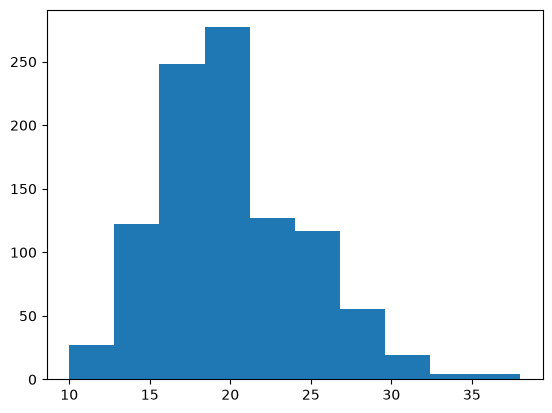

In [2]:
K = 1000
r = 5*2
p = 0.3 + 0.2
amostra_binneg = []
for _ in range(K):
    U = np.random.uniform()
    pi = p**r
    n = r
    F = pi
    
    while U > F:
        pi *= (1-p)*n/(n-r+1)
        n += 1 
        F += pi
    amostra_binneg.append(n)

plt.hist(amostra_binneg)


Aqui eu apenas usei a fórmula recursiva para gerar uma amostra de binomiais negativas

1.1.2 - Por Bernoullis

(array([ 52., 158., 264., 192., 162.,  78.,  64.,  13.,  15.,   2.]),
 array([ 5. ,  8.5, 12. , 15.5, 19. , 22.5, 26. , 29.5, 33. , 36.5, 40. ]),
 <BarContainer object of 10 artists>)

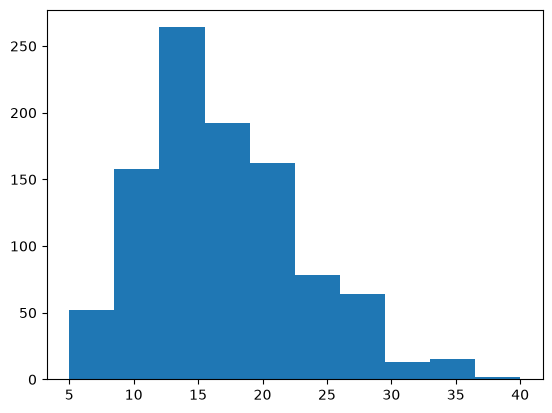

In [3]:
r = 5
p = 0.3
amostra = []
for _ in range(K):
    n = 0
    s = 0
    while s < r:
        B = np.random.uniform() < p
        n += 1 
        s += B
    amostra.append(n)

plt.hist(amostra)

Aqui eu gerei binomiais negativas a partir de bernoullis, sendo que cada bernoulli vai ate ter o número de sucessos que é o parâmetro da binomial negativa

1.1.3 - Por Geométricas

(array([ 95., 248., 335., 174.,  84.,  42.,  16.,   4.,   1.,   1.]),
 array([ 5. ,  9.4, 13.8, 18.2, 22.6, 27. , 31.4, 35.8, 40.2, 44.6, 49. ]),
 <BarContainer object of 10 artists>)

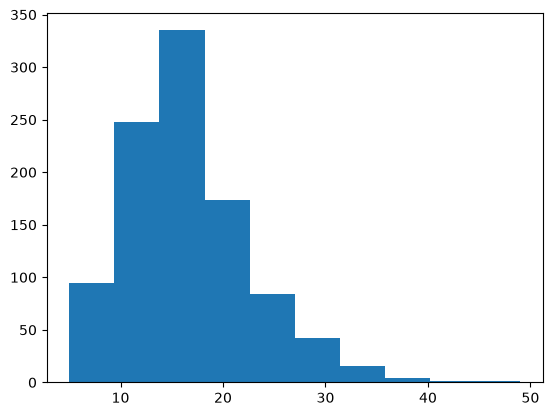

In [4]:
r = 5
p = 0.3
binomial_negativa = []
for _ in range(K):
    geometricas = []
    soma = 0
    for _ in range(r):
        U = np.random.uniform()
        x = np.floor(np.log(1-U)/np.log(1-p)) + 1
        geometricas.append(x)
        soma = sum(geometricas)
    binomial_negativa.append(soma)

plt.hist(binomial_negativa)
        


Aqui eu usei soma de geométricas para gerar as binomiais negativas

In [5]:
media_por_recursao = np.mean(amostra_binneg)
media_por_bernoullis = np.mean(amostra)
media_por_geometricas = np.mean(binomial_negativa)

print(f' A média pelo método de recursão foi: {media_por_recursao}')
print(f' A média pelo método por bernoullis foi: {media_por_bernoullis}')
print(f' A média pelo método por geométricas foi: {media_por_geometricas}')
print(f' A média gerada pelo numpy foi de {np.mean(np.random.negative_binomial(r,p, size=K))+r}')

 A média pelo método de recursão foi: 19.995
 A média pelo método por bernoullis foi: 16.661
 A média pelo método por geométricas foi: 16.517
 A média gerada pelo numpy foi de 16.53


Aqui eu apenas printei as médias as amostras de cada método, e percebe-se que elas são muito parecidas

1.2

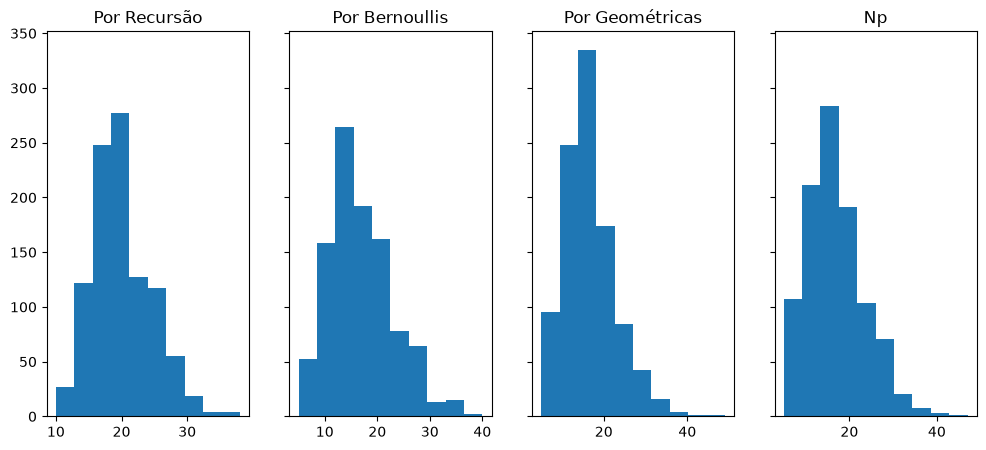

In [6]:
fig, ax = plt.subplots(1,4, figsize=(12,5), sharey=True)

ax[0].hist(amostra_binneg)
ax[0].set_title('Por Recursão')

ax[1].hist(amostra)
ax[1].set_title('Por Bernoullis')

ax[2].hist(binomial_negativa)
ax[2].set_title('Por Geométricas')


ax[3].hist(np.random.negative_binomial(r,p,size=K)+r)
ax[3].set_title('Np')

plt.show()

Aqui eu apenas plotei os histogramas para os métodos e pela função np e percebe-se que sao bem parecidas

# Exercício 2

1.  Gere uma amostra de tamanho $K$ de uma variável aleatória com distribuição hipergeométrica com parâmetros $M,N,n$ utilizando o método de embaralhamento de Fisher–Yates.
2.  No método de Fisher-Yates, no passo (a), a gente amostra um ponto para troca entre $i$ e $N$. Pense em qual seria o problema caso a gente sempre amostrasse entre $1$ e $N$. Compare o resultado final usando essas duas versões e uma amostra gerada pelo numpy.

In [11]:
K = 10000
M = 2
N = 15
n = 3
def hipergeometrica(M,N,n,K):
    hipers =[]
    for _ in range(K):
        lista = [1] * M + [0] * (N)
        for i in range(n):
            u = np.random.uniform()
            pos = int(np.floor(((N+M)-i)*u + i))
            lista[i],lista[pos] = lista[pos], lista[i]
        hipers.append(np.sum(lista[:n]))
    return hipers
hipers = hipergeometrica(M,N,n,K)

Aqui eu apenas criei uma função para gerar a hipergeométrica pelo método de embaralhamento 

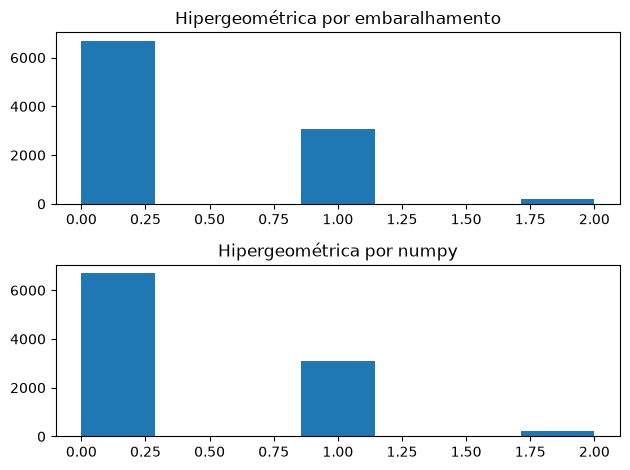

In [10]:
fig, ax = plt.subplots(2,1)
ax[0].hist(hipers, bins=7)
ax[0].set_title('Hipergeométrica por embaralhamento')
ax[1].hist(np.random.hypergeometric(M, N, n, size=K), bins=7)
ax[1].set_title('Hipergeométrica por numpy')
plt.tight_layout()
plt.show()

# Exercício 3

É intuitivo esperar que, quando o tamanho total da população $M+N$ cresce muito em relação ao tamanho da amostra $n$, o fato de a amostragem ser feita sem reposição passe a ter pouca importância, pois retirar um elemento altera muito pouco a composição da população restante. Nesse caso, cada retirada deve se comportar aproximadamente como um ensaio de Bernoulli independente, com probabilidade de sucesso

$$
p=\frac{N}{M+N}.
$$

Assim, esperamos que a distribuição hipergeométrica com parâmetros $M,N,n$ se aproxime de uma distribuição binomial com parâmetros $n$ e $p$.

Compare numericamente essas duas distribuições para valores crescentes de $M$ e $N$, mantendo aproximadamente constante a proporção

$$
\frac{N}{M+N}\to p,
$$

e mantendo $n$ fixo. Verifique, por meio de simulações, se a aproximação pela distribuição binomial melhora à medida que $M+N$ aumenta.


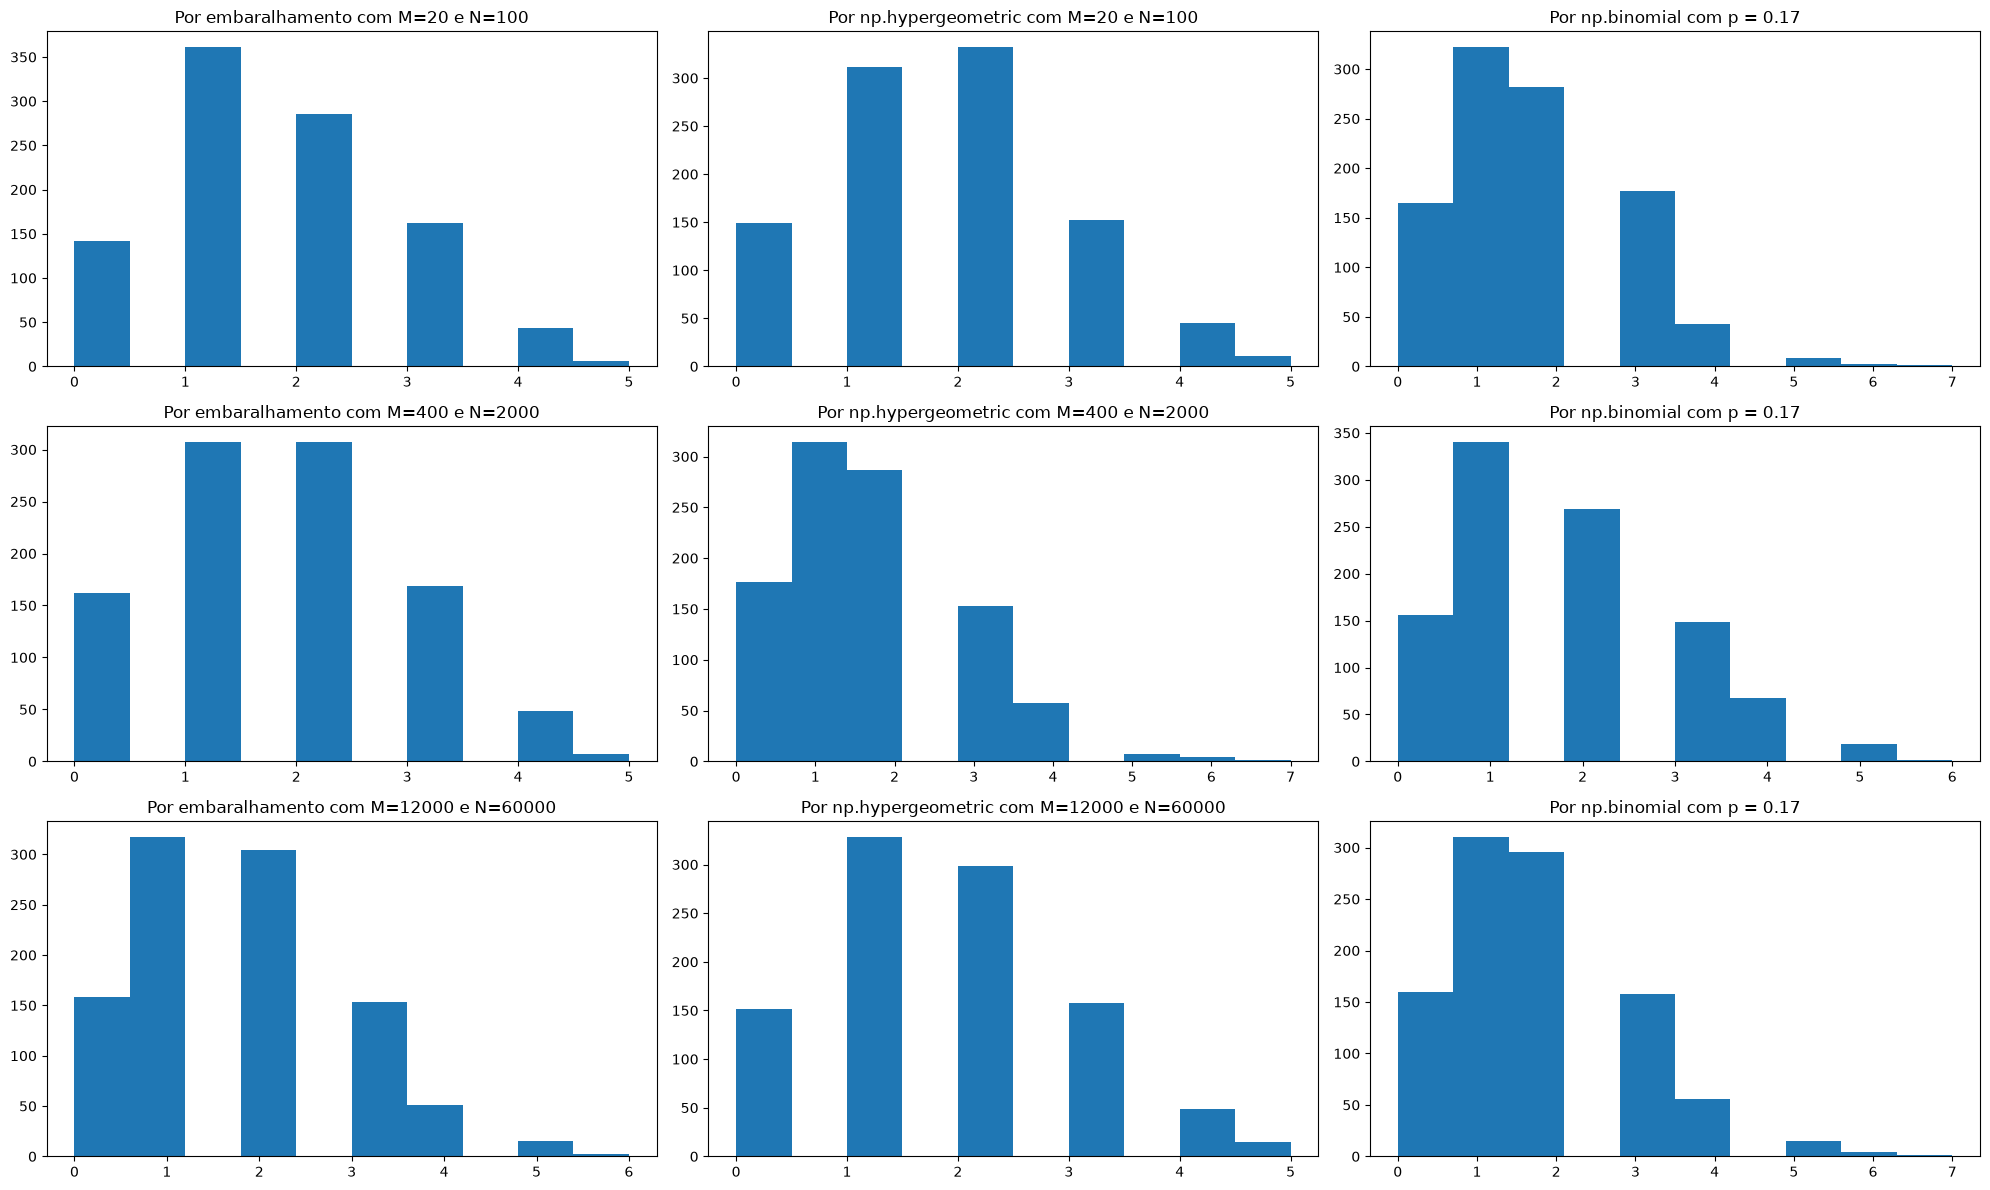

In [8]:
fig, ax = plt.subplots(3,3, figsize=(20,12))
N = 10
M = 2
n = 10
K = 1000
for i in range(3):
    M *= 10*(i+1)
    N *= 10*(i+1)
    hiper = hipergeometrica(M,N,n,K)
    ax[i][0].hist(hiper)
    ax[i][0].set_title(f'Por embaralhamento com M={M} e N={N}')
    ax[i][1].set_title(f'Por np.hypergeometric com M={M} e N={N}')
    ax[i][2].set_title(f'Por np.binomial com p = {M/(N+M):.2f}')
    ax[i][1].hist(np.random.hypergeometric(M,N,n, size=K))
    ax[i][2].hist(np.random.binomial(n, M/(M+N), size = K))
plt.tight_layout()